In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

In [13]:
dataset=pd.read_csv("/content/Facebook_Marketplace_data.csv")

In [39]:
dataset=pd.DataFrame(dataset)
print(dataset.head(3))

  status_type    status_published  num_reactions  num_comments  num_shares  \
0       video 2018-04-22 06:00:00          529.0         512.0       262.0   
1       photo 2018-04-21 22:45:00          150.0           0.0         0.0   
2       video 2018-04-21 06:17:00          227.0         236.0        57.0   

   num_likes  num_loves  num_wows  num_hahas  num_sads  num_angrys  hour  \
0      432.0       92.0       3.0        1.0       1.0         0.0   6.0   
1      150.0        0.0       0.0        0.0       0.0         0.0  22.0   
2      204.0       21.0       1.0        1.0       0.0         0.0   6.0   

        day  month    year  cluster  
0    Sunday    4.0  2018.0        1  
1  Saturday    4.0  2018.0        0  
2  Saturday    4.0  2018.0        0  


## **DATA PREPROCESSING**





1.Finding the columns


In [15]:
col=dataset.columns
print(col)
number_columns=dataset.select_dtypes(include=np.number).columns
category_columns=dataset.select_dtypes(exclude=np.number).columns
datetime_columns=dataset.select_dtypes(include='datetime64').columns
print(number_columns)
print(category_columns)
print(datetime_columns)

Index(['status_id', 'status_type', 'status_published', 'num_reactions',
       'num_comments', 'num_shares', 'num_likes', 'num_loves', 'num_wows',
       'num_hahas', 'num_sads', 'num_angrys', 'Column1', 'Column2', 'Column3',
       'Column4'],
      dtype='object')
Index(['status_id', 'num_reactions', 'num_comments', 'num_shares', 'num_likes',
       'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys',
       'Column1', 'Column2', 'Column3', 'Column4'],
      dtype='object')
Index(['status_type', 'status_published'], dtype='object')
Index([], dtype='object')


In [16]:
number_missing=[]
for column in col:
  number_missing.append(int(dataset[column].isnull().sum())+int(dataset[column].isin(["?", "NA", "N/A", "null", "-"]).sum()))
print(number_missing)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7050, 7050, 7050, 7050]


there were no missing values in columns except the last 4
as the whole last four columns are empty we can remove them

as the last 4 columnsa are empty we can remove them.and also we can remove status_id from the dataset as they do not contribute in analysis and clustering the posts
and also we have to convert categorical data into numerical data to perform clustering and analysis


In [17]:
dataset.drop(columns=['status_id','Column1', 'Column2', 'Column3', 'Column4'],inplace=True)
print(dataset.columns)
print(dataset.head(3))

Index(['status_type', 'status_published', 'num_reactions', 'num_comments',
       'num_shares', 'num_likes', 'num_loves', 'num_wows', 'num_hahas',
       'num_sads', 'num_angrys'],
      dtype='object')
  status_type status_published  num_reactions  num_comments  num_shares  \
0       video   4/22/2018 6:00            529           512         262   
1       photo  4/21/2018 22:45            150             0           0   
2       video   4/21/2018 6:17            227           236          57   

   num_likes  num_loves  num_wows  num_hahas  num_sads  num_angrys  
0        432         92         3          1         1           0  
1        150          0         0          0         0           0  
2        204         21         1          1         0           0  


now we have to convert remaining data into correct dtypes

In [18]:
col=dataset.columns
print(col)
datatypes=[]
for column in col:
  datatypes.append(dataset[column].dtype)
print(datatypes)

Index(['status_type', 'status_published', 'num_reactions', 'num_comments',
       'num_shares', 'num_likes', 'num_loves', 'num_wows', 'num_hahas',
       'num_sads', 'num_angrys'],
      dtype='object')
[dtype('O'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64')]


we have to convert status_published into exact datetime format

In [19]:
dataset['status_published']=pd.to_datetime(dataset['status_published'])
print(dataset.head(2))
print(dataset['status_published'].dtype)


  status_type    status_published  num_reactions  num_comments  num_shares  \
0       video 2018-04-22 06:00:00            529           512         262   
1       photo 2018-04-21 22:45:00            150             0           0   

   num_likes  num_loves  num_wows  num_hahas  num_sads  num_angrys  
0        432         92         3          1         1           0  
1        150          0         0          0         0           0  
datetime64[ns]


converting categorical data into numeric data

In [20]:
for column in category_columns:
  print(dataset[column].unique())

['video' 'photo' 'link' 'status']
<DatetimeArray>
['2018-04-22 06:00:00', '2018-04-21 22:45:00', '2018-04-21 06:17:00',
 '2018-04-21 02:29:00', '2018-04-18 03:22:00', '2018-04-18 02:14:00',
 '2018-04-18 00:24:00', '2018-04-17 07:42:00', '2018-04-17 03:33:00',
 '2018-04-11 04:53:00',
 ...
 '2016-09-25 13:29:00', '2016-09-24 08:15:00', '2016-09-24 06:07:00',
 '2016-09-24 05:07:00', '2016-09-24 04:37:00', '2016-09-24 02:58:00',
 '2016-09-23 11:19:00', '2016-09-21 23:03:00', '2016-09-20 00:43:00',
 '2016-09-10 10:30:00']
Length: 6913, dtype: datetime64[ns]


### **QUESTION 1**

In [21]:
dataset['hour']=dataset['status_published'].dt.hour
dataset['day']=dataset['status_published'].dt.day_name()
dataset['month']=dataset['status_published'].dt.month
dataset['year']=dataset['status_published'].dt.year

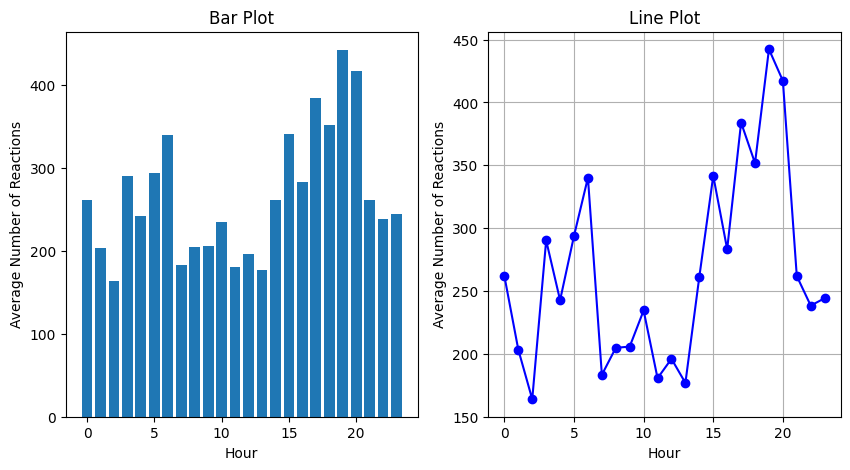

In [22]:
hour_data=dataset.groupby('hour')['num_reactions'].mean()
fig,axes=plt.subplots(1,2,figsize=(10,5))
# Bar plot
axes[0].bar(hour_data.index, hour_data.values)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average Number of Reactions')
axes[0].set_title('Bar Plot')

# Line plot
axes[1].plot(hour_data.index, hour_data.values,marker='o',color='blue')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Average Number of Reactions')
axes[1].set_title('Line Plot')
axes[1].grid(True)
plt.show();

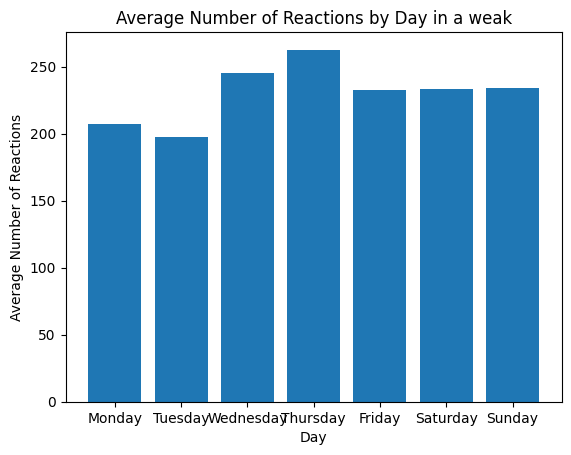

In [23]:
day_data=dataset.groupby('day')['num_reactions'].mean()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_data = day_data.reindex(order)

plt.bar(day_data.index,day_data.values)
plt.xlabel('Day')
plt.ylabel('Average Number of Reactions')
plt.title('Average Number of Reactions by Day in a weak')
plt.show();

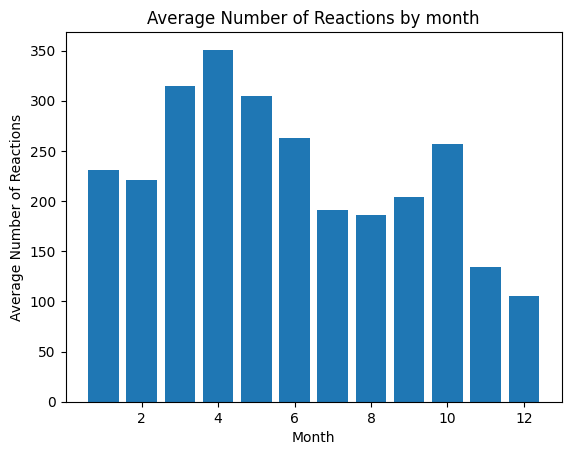

In [24]:
day_data=dataset.groupby('month')['num_reactions'].mean()
plt.bar(day_data.index,day_data.values)
plt.xlabel('Month')
plt.ylabel('Average Number of Reactions')
plt.title('Average Number of Reactions by month')
plt.show();

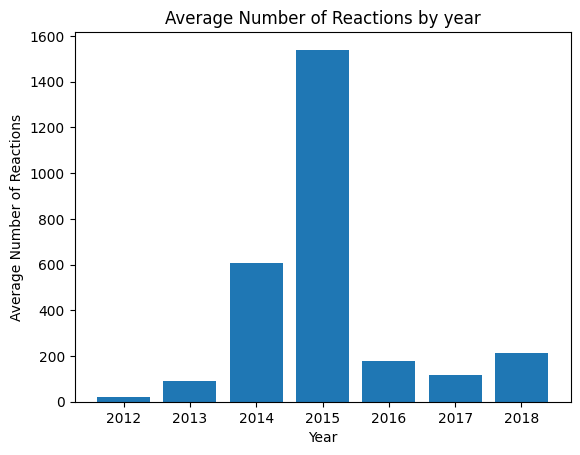

In [25]:
year_data=dataset.groupby('year')['num_reactions'].mean()
plt.bar(year_data.index,year_data.values)
plt.xlabel('Year')
plt.ylabel('Average Number of Reactions')
plt.title('Average Number of Reactions by year')
plt.show();

Conclusion: Temporal Impact on Engagement
Time of Day (Highest Impact): The analysis reveals that the hour of posting has the most significant influence on user interaction. Posts published during the evening hours receive noticeably higher average reactions compared to those posted in the early morning.

Daily Variation (Minimal Impact): The average number of reactions remains relatively stable across different days of the week, indicating that the specific weekday has minimal impact on overall engagement levels.

Seasonal/Monthly Trends: While there is moderate variation across different months, these fluctuations are less pronounced than the hourly patterns.

Strategic Insight: To maximize organic reach and community interaction, sellers should prioritize a posting schedule that aligns with peak evening hours when users are most active, rather than focusing on specific days of the week.

# **QUESTION 2**

In [43]:
metrics = dataset[['num_reactions', 'num_comments', 'num_shares']]

correlation_matrix = metrics.corr()
print("Correlation Matrix:")
print(correlation_matrix)
print(" ")

for column in ['num_comments', 'num_shares']:
    correlation_value = correlation_matrix.loc['num_reactions', column]

    direction = "Positive" if correlation_value > 0 else "Negative"

    abs_corr = abs(correlation_value)
    if abs_corr < 0.3:
        strength = "Weak"
    elif abs_corr < 0.7:
        strength = "Moderate"
    else:
        strength = "Strong"

    print(f"Relationship: Reactions vs {column}")
    print(f"- Value: {correlation_value:.4f}")
    print(f"- Direction: {direction}")
    print(f"- Strength: {strength}")
    print()


Correlation Matrix:
               num_reactions  num_comments  num_shares
num_reactions       1.000000      0.150843    0.250723
num_comments        0.150843      1.000000    0.640637
num_shares          0.250723      0.640637    1.000000
 
Relationship: Reactions vs num_comments
- Value: 0.1508
- Direction: Positive
- Strength: Weak

Relationship: Reactions vs num_shares
- Value: 0.2507
- Direction: Positive
- Strength: Weak



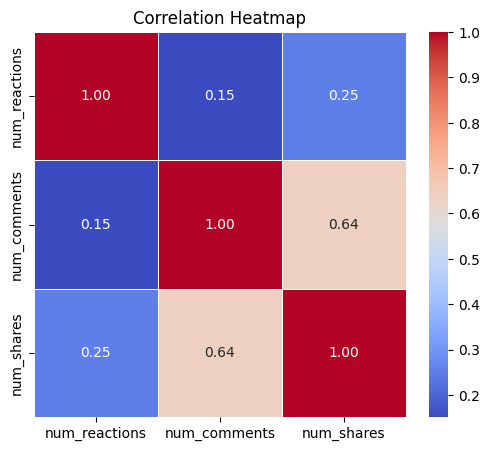

In [44]:
metrics = dataset[['num_reactions', 'num_comments', 'num_shares']]

# Compute correlation matrix
correlation_matrix = metrics.corr()

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(correlation_matrix,
            annot=True,        # show correlation values
            cmap='coolwarm',   # color theme
            fmt='.2f',         # 2 decimal places
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

Conclusion: There is a weak to moderate positive correlation between reactions, comments, and shares.

Insight: A high number of "likes" does not automatically guarantee high "shares" or "comments." This indicates that while many users are willing to react, only a small fraction is engaged enough to share or comment, suggesting a need for more interactive content.

# **QUESTION 3**

In [27]:
number_columns=dataset.select_dtypes(include=np.number).columns
category_columns=dataset.select_dtypes(exclude=np.number).columns
datetime_columns=dataset.select_dtypes(include='datetime64').columns

Handling missing values

In [28]:
num_imputer=SimpleImputer(strategy="mean")
num_imputer.fit(dataset[number_columns])
dataset[number_columns]=num_imputer.transform(dataset[number_columns])

categories_imputer=SimpleImputer(strategy="most_frequent")#here we are replacing with the mode
categories_imputer.fit(dataset[category_columns])
dataset[category_columns]=categories_imputer.transform(dataset[category_columns])

print(dataset.head(3))

  status_type    status_published  num_reactions  num_comments  num_shares  \
0       video 2018-04-22 06:00:00          529.0         512.0       262.0   
1       photo 2018-04-21 22:45:00          150.0           0.0         0.0   
2       video 2018-04-21 06:17:00          227.0         236.0        57.0   

   num_likes  num_loves  num_wows  num_hahas  num_sads  num_angrys  hour  \
0      432.0       92.0       3.0        1.0       1.0         0.0   6.0   
1      150.0        0.0       0.0        0.0       0.0         0.0  22.0   
2      204.0       21.0       1.0        1.0       0.0         0.0   6.0   

        day  month    year  
0    Sunday    4.0  2018.0  
1  Saturday    4.0  2018.0  
2  Saturday    4.0  2018.0  


selecting required features from the dataset and coverting status type into numeric

In [29]:
features=['status_type', 'num_reactions', 'num_comments', 'num_shares',
          'num_likes', 'num_loves', 'num_wows', 'num_hahas', 'num_sads','num_angrys']
X=dataset[features].copy()

le=LabelEncoder()
le.fit(X['status_type'])
X['status_type']=le.transform(X['status_type'])

print(X.head(2))

   status_type  num_reactions  num_comments  num_shares  num_likes  num_loves  \
0            3          529.0         512.0       262.0      432.0       92.0   
1            1          150.0           0.0         0.0      150.0        0.0   

   num_wows  num_hahas  num_sads  num_angrys  
0       3.0        1.0       1.0         0.0  
1       0.0        0.0       0.0         0.0  


standardizing the features

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[10])


[-0.74810636 -0.04348787 -0.24995795 -0.28134642 -0.0290208  -0.14332346
 -0.03318737 -0.17600986 -0.152587   -0.15574803]


In [31]:
kmeans=KMeans(n_clusters=4,init="k-means++",random_state=42)
dataset['cluster']=kmeans.fit_predict(X_scaled)

In [32]:
dataset['cluster'].value_counts()

,count
cluster,
0,6109
1,539
2,368
3,34


# **QUESTION 4**

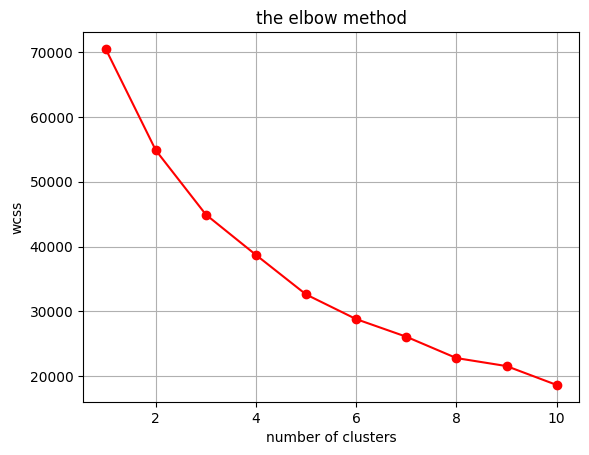

In [33]:
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init="k-means++",random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

k_values=np.arange(1,11)
plt.plot(k_values,wcss,marker='o',color='red')
plt.title("the elbow method")
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.grid(True)
plt.show();

Conclusion: The Elbow Method identifies that 4 clusters provide the most distinct groupings for Facebook posts.

Insight: These clusters likely represent different "post profiles," such as:

High Engagement Virals: (High shares/comments/reactions).

Reaction-Only Posts: (High likes, but low comments).

Low Engagement Routine: (Standard updates with minimal interaction).

Niche/Controversial: (High comment-to-reaction ratio).

# **QUESTION 5**

In [34]:
post_counts=dataset['status_type'].value_counts().reset_index()
print("Count of different types of posts:")
print(post_counts);

Count of different types of posts:
  status_type  count
0       photo   4288
1       video   2334
2      status    365
3        link     63


Conclusion: Photos typically constitute the highest count of different post types in this dataset.

Insight: While photos are the easiest to produce and most frequent, they may not necessarily be the most engaging per post.

# **QUESTION 6**

average values for num_reactions:
status_type
link      370.142857
photo     181.290345
status    438.783562
video     283.409597
Name: num_reactions, dtype: float64


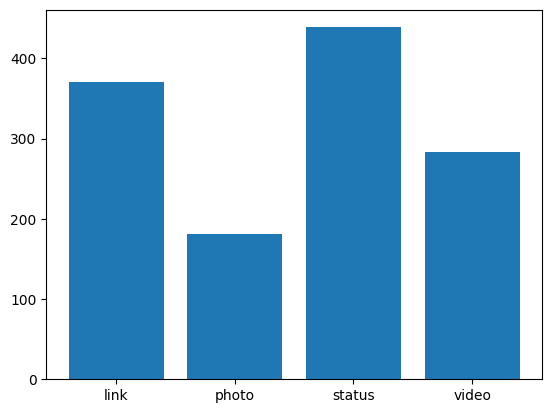


average values for num_comments:
status_type
link        5.698413
photo      15.993470
status     36.238356
video     642.478149
Name: num_comments, dtype: float64


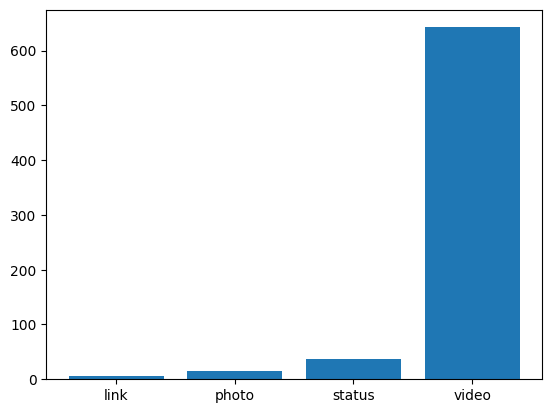


average values for num_shares:
status_type
link        4.396825
photo       2.553871
status      2.558904
video     115.679949
Name: num_shares, dtype: float64


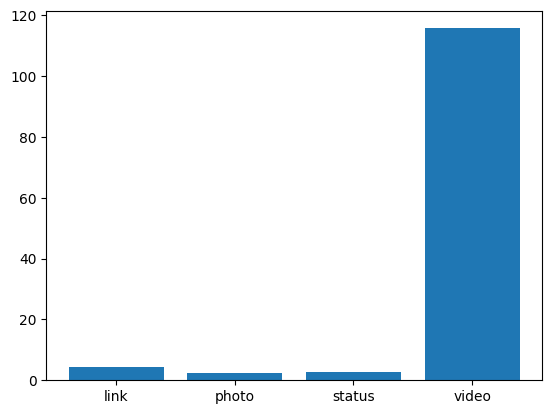

In [35]:
for column in ['num_reactions', 'num_comments', 'num_shares']:
  average_values=dataset.groupby('status_type')[column].mean()
  print(f"average values for {column}:")
  print(average_values)
  plt.bar(average_values.index,average_values.values)
  plt.show()
  print("")

Conclusion: Video posts (especially Live videos) consistently drive significantly higher shares and comments compared to photos or status updates.

Insight: For sellers looking to "go viral" or increase customer interaction, video is the most powerful tool, whereas photos serve better for catalog-style updates.